# PR-x-delta-mean
6.25.25

Same thing as the previous notebook, except that here the thing we're varying within the 
precision-recall curves is the perturb index, that is, the multiplier that we use to generate
the differentially expressed proteins in the condition B matrix. Smaller values of the perturb
index indicate that the means in conditionA and conditionB are closer, meaning the differential
abundance identification task is more challenging. 

Here we're keeping the missingness fraction constant; right now it's set to 0.2. 

In [1]:
import pandas as pd
import numpy as np
from scipy import stats
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import auc
from sklearn.metrics import precision_recall_curve

# plotting templates
sns.set(context="talk", style="ticks") 
sns.set_palette("tab10")

/net/noble/vol2/home/lincolnh/miniconda3/envs/deep-impute/lib/python3.9/site-packages/threadpoolctl.py:1214: RuntimeWarning: 
Found Intel OpenMP ('libiomp') and LLVM OpenMP ('libomp') loaded at
the same time. Both libraries are known to be incompatible and this
can cause random crashes or deadlocks on Linux when loaded in the
same Python program.
Using threadpoolctl may cause crashes or deadlocks. For more
information and possible workarounds, please see
    https://github.com/joblib/threadpoolctl/blob/master/multiple_openmp.md

  warnings.warn(msg, RuntimeWarning)


#### Configs

In [2]:
nruns=128

#### Functions

In [3]:
def bh_adjustment(pvals):
    """
    Performs the Benjamini-Hochberg procedure
    for p-value ADJUSTMENT. So this means we actually 
    return a list of corrected p-values, not just a 
    boolean specifying which p-values to keep per the
    FDR controlled at some threshold. 
    
    Parameters
    ----------
    pvals : np.ndarray, 
        The sorted list of uncorrected p-values. Sorted
        from smallest to largest

    Returns
    -----------
    pvals_adjusted : list, 
        A list of the BH adjusted p-values
    """
    pvals_adjusted = []

    for i in range(0, len(pvals)):
        rank = i + 1
        curr_pval = pvals[i]
        pval_adj = (curr_pval * len(pvals)) / rank
        pvals_adjusted.append(pval_adj)        

    return pvals_adjusted

def get_rank_sum_stats(mat0, mat1):
    """
    Performs a Wilcoxon rank-sum test for every protein, for two experimental conditions. 

    Parameters
    ----------
    mat0, mat1 : np.ndarray, 
        The two input matrices, one for each condition. 

    Returns
    ----------
    pvals : list,
        The (uncorrected) p-values
    rs_stats : list, 
        The rank-sum statistics 
    """
    pvals = []
    rs_stats = []
    
    for i in range(0, mat0.shape[0]):
        stat, pval = stats.ranksums(mat0[i], mat1[i], nan_policy="omit")
        pvals.append(pval)
        rs_stats.append(stat)

    return pvals, rs_stats

#### Read in the Lupine imputed simulated quants matrices 

In [4]:
# Read in our impute matrices 
lupine_01 = pd.read_csv("../vary-mean-results/lupine-quant-simulated-mv-02-p-01-46418351.csv", index_col=0)
lupine_02 = pd.read_csv("../vary-mean-results/lupine-quant-simulated-mv-02-p-02-40476907.csv", index_col=0)
lupine_04 = pd.read_csv("../vary-mean-results/lupine-quant-simulated-mv-02-p-04-61041420.csv", index_col=0)
lupine_08 = pd.read_csv("../vary-mean-results/lupine-quant-simulated-mv-02-p-08-85249653.csv", index_col=0)
lupine_10 = pd.read_csv("../vary-mean-results/lupine-quant-simulated-mv-02-p-10-78852044.csv", index_col=0)
lupine_20 = pd.read_csv("../vary-mean-results/lupine-quant-simulated-mv-02-p-20-87678094.csv", index_col=0)
lupine_40 = pd.read_csv("../vary-mean-results/lupine-quant-simulated-mv-02-p-40-42186104.csv", index_col=0)
lupine_80 = pd.read_csv("../vary-mean-results/lupine-quant-simulated-mv-02-p-80-71409111.csv", index_col=0)
lupine_100 = pd.read_csv("../vary-mean-results/lupine-quant-simulated-mv-02-p-100-78707773.csv", index_col=0)
lupine_200 = pd.read_csv("../vary-mean-results/lupine-quant-simulated-mv-02-p-200-49510092.csv", index_col=0)

# Read in the ground truth dataframe, solely for the purpose of getting the column IDs
gt_df = pd.read_csv("../vary-mean-data/quant-simulated-mv-02-p-01.csv", index_col=0)

# Read in the list of ground truth DA proteins
da_gt_01 = pd.read_csv("../vary-mean-data/groundtruth-mv-02-p-01.csv", index_col=0)
da_gt_02 = pd.read_csv("../vary-mean-data/groundtruth-mv-02-p-02.csv", index_col=0)
da_gt_04 = pd.read_csv("../vary-mean-data/groundtruth-mv-02-p-04.csv", index_col=0)
da_gt_08 = pd.read_csv("../vary-mean-data/groundtruth-mv-02-p-08.csv", index_col=0)
da_gt_10 = pd.read_csv("../vary-mean-data/groundtruth-mv-02-p-10.csv", index_col=0)
da_gt_20 = pd.read_csv("../vary-mean-data/groundtruth-mv-02-p-20.csv", index_col=0)
da_gt_40 = pd.read_csv("../vary-mean-data/groundtruth-mv-02-p-40.csv", index_col=0)
da_gt_80 = pd.read_csv("../vary-mean-data/groundtruth-mv-02-p-80.csv", index_col=0)
da_gt_100 = pd.read_csv("../vary-mean-data/groundtruth-mv-02-p-100.csv", index_col=0)
da_gt_200 = pd.read_csv("../vary-mean-data/groundtruth-mv-02-p-200.csv", index_col=0)

lupine_01.columns = gt_df.columns
lupine_02.columns = gt_df.columns
lupine_04.columns = gt_df.columns
lupine_08.columns = gt_df.columns
lupine_10.columns = gt_df.columns
lupine_20.columns = gt_df.columns
lupine_40.columns = gt_df.columns
lupine_80.columns = gt_df.columns
lupine_100.columns = gt_df.columns
lupine_200.columns = gt_df.columns

lupine_01.index = gt_df.index
lupine_02.index = gt_df.index
lupine_04.index = gt_df.index
lupine_08.index = gt_df.index
lupine_10.index = gt_df.index
lupine_20.index = gt_df.index
lupine_40.index = gt_df.index
lupine_80.index = gt_df.index
lupine_100.index = gt_df.index
lupine_200.index = gt_df.index

#### Separate out into the two different conditions 

In [5]:
cond0_lupine_01 = np.array(lupine_01.iloc[:, :nruns])
cond1_lupine_01 = np.array(lupine_01.iloc[:, nruns:])

cond0_lupine_02 = np.array(lupine_02.iloc[:, :nruns])
cond1_lupine_02 = np.array(lupine_02.iloc[:, nruns:])

cond0_lupine_04 = np.array(lupine_04.iloc[:, :nruns])
cond1_lupine_04 = np.array(lupine_04.iloc[:, nruns:])

cond0_lupine_08 = np.array(lupine_08.iloc[:, :nruns])
cond1_lupine_08 = np.array(lupine_08.iloc[:, nruns:])

cond0_lupine_10 = np.array(lupine_10.iloc[:, :nruns])
cond1_lupine_10 = np.array(lupine_10.iloc[:, nruns:])

cond0_lupine_20 = np.array(lupine_20.iloc[:, :nruns])
cond1_lupine_20 = np.array(lupine_20.iloc[:, nruns:])

cond0_lupine_40 = np.array(lupine_40.iloc[:, :nruns])
cond1_lupine_40 = np.array(lupine_40.iloc[:, nruns:])

cond0_lupine_80 = np.array(lupine_80.iloc[:, :nruns])
cond1_lupine_80 = np.array(lupine_80.iloc[:, nruns:])

cond0_lupine_100 = np.array(lupine_100.iloc[:, :nruns])
cond1_lupine_100 = np.array(lupine_100.iloc[:, nruns:])

cond0_lupine_200 = np.array(lupine_200.iloc[:, :nruns])
cond1_lupine_200 = np.array(lupine_200.iloc[:, nruns:])

#### Calculate the Wilcoxon rank-sum test statistics 

In [6]:
pvals_lupine_01, _ = get_rank_sum_stats(cond0_lupine_01, cond1_lupine_01)
pvals_lupine_02, _ = get_rank_sum_stats(cond0_lupine_02, cond1_lupine_02)
pvals_lupine_04, _ = get_rank_sum_stats(cond0_lupine_04, cond1_lupine_04)
pvals_lupine_08, _ = get_rank_sum_stats(cond0_lupine_08, cond1_lupine_08)
pvals_lupine_10, _ = get_rank_sum_stats(cond0_lupine_10, cond1_lupine_10)
pvals_lupine_20, _ = get_rank_sum_stats(cond0_lupine_20, cond1_lupine_20)
pvals_lupine_40, _ = get_rank_sum_stats(cond0_lupine_40, cond1_lupine_40)
pvals_lupine_80, _ = get_rank_sum_stats(cond0_lupine_80, cond1_lupine_80)
pvals_lupine_100, _ = get_rank_sum_stats(cond0_lupine_100, cond1_lupine_100)
pvals_lupine_200, _ = get_rank_sum_stats(cond0_lupine_200, cond1_lupine_200)

#### Init a stats dataframe

In [7]:
# Init a stats dataframe 
colnames = ["ENSP","lupine_pval_01", "lupine_pval_02", "lupine_pval_04", "lupine_pval_008", 
            "lupine_pval_10", "lupine_pval_20", "lupine_pval_40", "lupine_pval_80",
            "lupine_pval_100", "lupine_pval_200"]

stats_df = pd.DataFrame(columns=colnames)
stats_df["ENSP"] = lupine_01.index
stats_df["lupine_pval_01"] = pvals_lupine_01
stats_df["lupine_pval_02"] = pvals_lupine_02
stats_df["lupine_pval_04"] = pvals_lupine_04
stats_df["lupine_pval_08"] = pvals_lupine_08
stats_df["lupine_pval_10"] = pvals_lupine_10
stats_df["lupine_pval_20"] = pvals_lupine_20
stats_df["lupine_pval_40"] = pvals_lupine_40
stats_df["lupine_pval_80"] = pvals_lupine_80
stats_df["lupine_pval_100"] = pvals_lupine_100
stats_df["lupine_pval_200"] = pvals_lupine_200

#### Get the ground truth differentially abundant protein IDs 

In [8]:
upreg_ensp_01 = list(da_gt_01["upreg"])
downreg_ensp_01 = list(da_gt_01["downreg"])
diff_ensp_gt_01 = upreg_ensp_01 + downreg_ensp_01

upreg_ensp_02 = list(da_gt_02["upreg"])
downreg_ensp_02 = list(da_gt_02["downreg"])
diff_ensp_gt_02 = upreg_ensp_02 + downreg_ensp_02

upreg_ensp_04 = list(da_gt_04["upreg"])
downreg_ensp_04 = list(da_gt_04["downreg"])
diff_ensp_gt_04 = upreg_ensp_04 + downreg_ensp_04

upreg_ensp_08 = list(da_gt_08["upreg"])
downreg_ensp_08 = list(da_gt_08["downreg"])
diff_ensp_gt_08 = upreg_ensp_08 + downreg_ensp_08

upreg_ensp_10 = list(da_gt_10["upreg"])
downreg_ensp_10 = list(da_gt_10["downreg"])
diff_ensp_gt_10 = upreg_ensp_10 + downreg_ensp_10

upreg_ensp_20 = list(da_gt_20["upreg"])
downreg_ensp_20 = list(da_gt_20["downreg"])
diff_ensp_gt_20 = upreg_ensp_20 + downreg_ensp_20

upreg_ensp_40 = list(da_gt_40["upreg"])
downreg_ensp_40 = list(da_gt_40["downreg"])
diff_ensp_gt_40 = upreg_ensp_40 + downreg_ensp_40

upreg_ensp_80 = list(da_gt_80["upreg"])
downreg_ensp_80 = list(da_gt_80["downreg"])
diff_ensp_gt_80 = upreg_ensp_80 + downreg_ensp_80

upreg_ensp_100 = list(da_gt_100["upreg"])
downreg_ensp_100 = list(da_gt_100["downreg"])
diff_ensp_gt_100 = upreg_ensp_100 + downreg_ensp_100

upreg_ensp_200 = list(da_gt_200["upreg"])
downreg_ensp_200 = list(da_gt_200["downreg"])
diff_ensp_gt_200 = upreg_ensp_200 + downreg_ensp_200

#### Get binary vectors representing the ground truth differential abundance labels

In [9]:
gt_labels_01 = [x in diff_ensp_gt_01 for x in stats_df["ENSP"]]
gt_labels_01 = np.array(gt_labels_01)*1

gt_labels_02 = [x in diff_ensp_gt_02 for x in stats_df["ENSP"]]
gt_labels_02 = np.array(gt_labels_02)*1

gt_labels_04 = [x in diff_ensp_gt_04 for x in stats_df["ENSP"]]
gt_labels_04 = np.array(gt_labels_04)*1

gt_labels_08 = [x in diff_ensp_gt_08 for x in stats_df["ENSP"]]
gt_labels_08 = np.array(gt_labels_08)*1

gt_labels_10 = [x in diff_ensp_gt_10 for x in stats_df["ENSP"]]
gt_labels_10 = np.array(gt_labels_10)*1

gt_labels_20 = [x in diff_ensp_gt_20 for x in stats_df["ENSP"]]
gt_labels_20 = np.array(gt_labels_20)*1

gt_labels_40 = [x in diff_ensp_gt_40 for x in stats_df["ENSP"]]
gt_labels_40 = np.array(gt_labels_40)*1

gt_labels_80 = [x in diff_ensp_gt_80 for x in stats_df["ENSP"]]
gt_labels_80 = np.array(gt_labels_80)*1

gt_labels_100 = [x in diff_ensp_gt_100 for x in stats_df["ENSP"]]
gt_labels_100 = np.array(gt_labels_100)*1

gt_labels_200 = [x in diff_ensp_gt_200 for x in stats_df["ENSP"]]
gt_labels_200 = np.array(gt_labels_200)*1

#### Get the precision-recall statistics 

In [10]:
# FOR THE VARY 1% DATASET
pvals_01 = stats_df["lupine_pval_01"]
scores_01 = -np.log10(pvals_01)

pr_01, recall_01, _ = precision_recall_curve(y_true=gt_labels_01, y_score=scores_01)
auc_01 = auc(recall_01, pr_01)

# FOR THE VARY 2% DATASET
pvals_02 = stats_df["lupine_pval_02"]
scores_02 = -np.log10(pvals_02)

pr_02, recall_02, _ = precision_recall_curve(y_true=gt_labels_02, y_score=scores_02)
auc_02 = auc(recall_02, pr_02)

# FOR THE VARY 4% DATASET
pvals_04 = stats_df["lupine_pval_04"]
scores_04 = -np.log10(pvals_04)

pr_04, recall_04, _ = precision_recall_curve(y_true=gt_labels_04, y_score=scores_04)
auc_04 = auc(recall_04, pr_04)

# FOR THE VARY 8% DATASET
pvals_08 = stats_df["lupine_pval_08"]
scores_08 = -np.log10(pvals_08)

pr_08, recall_08, _ = precision_recall_curve(y_true=gt_labels_08, y_score=scores_08)
auc_08 = auc(recall_08, pr_08)

# FOR THE VARY 10% DATASET
pvals_10 = stats_df["lupine_pval_10"]
scores_10 = -np.log10(pvals_10)

pr_10, recall_10, _ = precision_recall_curve(y_true=gt_labels_10, y_score=scores_10)
auc_10 = auc(recall_10, pr_10)

# FOR THE VARY 20% DATASET
pvals_20 = stats_df["lupine_pval_20"]
scores_20 = -np.log10(pvals_20)

pr_20, recall_20, _ = precision_recall_curve(y_true=gt_labels_20, y_score=scores_20)
auc_20 = auc(recall_20, pr_20)

# FOR THE VARY 40% DATASET
pvals_40 = stats_df["lupine_pval_40"]
scores_40 = -np.log10(pvals_40)

pr_40, recall_40, _ = precision_recall_curve(y_true=gt_labels_40, y_score=scores_40)
auc_40 = auc(recall_40, pr_40)

# FOR THE VARY 80% DATASET
pvals_80 = stats_df["lupine_pval_80"]
scores_80 = -np.log10(pvals_80)

pr_80, recall_80, _ = precision_recall_curve(y_true=gt_labels_80, y_score=scores_80)
auc_80 = auc(recall_80, pr_80)

# FOR THE VARY 100% DATASET
pvals_100 = stats_df["lupine_pval_100"]
scores_100 = -np.log10(pvals_100)

pr_100, recall_100, _ = precision_recall_curve(y_true=gt_labels_100, y_score=scores_100)
auc_100 = auc(recall_100, pr_100)

# FOR THE VARY 200% DATASET
pvals_200 = stats_df["lupine_pval_200"]
scores_200 = -np.log10(pvals_200)

pr_200, recall_200, _ = precision_recall_curve(y_true=gt_labels_200, y_score=scores_200)
auc_200 = auc(recall_200, pr_200)

#### Plot! 

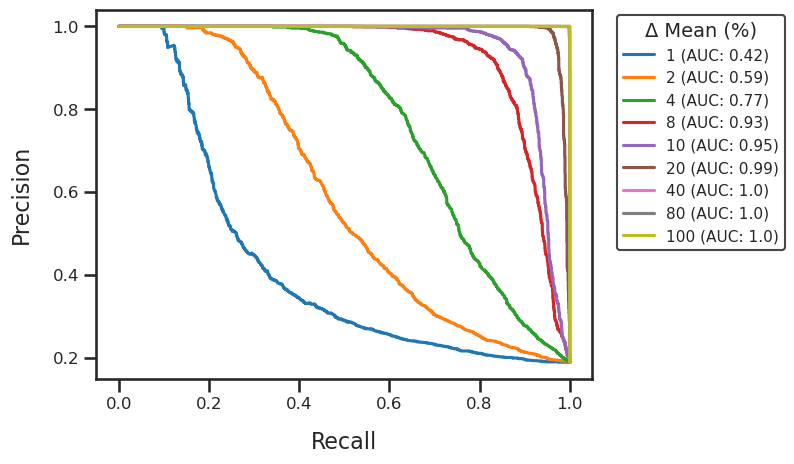

In [17]:
plt.figure()

plt.plot(recall_01, pr_01, label="1 (AUC: " + str(np.around(auc_01,2)) + ")")
plt.plot(recall_02, pr_02, label="2 (AUC: " + str(np.around(auc_02,2)) + ")")
plt.plot(recall_04, pr_04, label="4 (AUC: " + str(np.around(auc_04,2)) + ")")
plt.plot(recall_08, pr_08, label="8 (AUC: " + str(np.around(auc_08,2)) + ")")
plt.plot(recall_10, pr_10, label="10 (AUC: " + str(np.around(auc_10,2)) + ")")
plt.plot(recall_20, pr_20, label="20 (AUC: " + str(np.around(auc_20,2)) + ")")
plt.plot(recall_40, pr_40, label="40 (AUC: " + str(np.around(auc_40,2)) + ")")
plt.plot(recall_80, pr_80, label="80 (AUC: " + str(np.around(auc_80,2)) + ")")
plt.plot(recall_100, pr_100, label="100 (AUC: " + str(np.around(auc_100,2)) + ")")
#plt.plot(recall_200, pr_200, label="200")

plt.xlabel("Recall", size=16, labelpad=14)
plt.ylabel("Precision", size=16, labelpad=14)
plt.legend(title="Δ Mean (%)", edgecolor="k", title_fontsize=14, 
           prop={'size': 11}, loc=(1.05, 0.35))

plt.tick_params(axis='both', which='major', labelsize=12)
plt.locator_params(axis='y', min_n_ticks=4, nbins=6, tight="true")

#plt.show()
#plt.savefig("../figures/precision-recall-curves-protwise-simulation-vary-delta-mean.png", dpi=300, bbox_inches="tight")
#plt.savefig("../figures/precision-recall-curves-protwise-simulation-vary-delta-mean.pdf", bbox_inches="tight")